# FEATURE ENGINEERING OF FINLORA FINANCE DATA

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
import os
import joblib
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

## Load the Cleaned Finlora Dataset:

In [2]:
# Load finlora data file
finlora_data = pd.read_csv(
    r"C:\Users\User\Documents\10anlyticsDS\Projects\PersonalPJ\AMDARI_PJ\Dataset\preprocessed_data\Cleaned_Finlora_data.csv")

# Data Summary
finlora_summary = pd.DataFrame({
    "Data Type": finlora_data.dtypes.astype(str),
    "Missing Values": finlora_data.isna().sum(),
    "% Missing Values": (finlora_data.isna().mean() * 100).round(2),
    "Unique Values": finlora_data.nunique(),
    "Duplicate Values": [finlora_data.duplicated(subset=[col]).sum() for col in finlora_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

finlora_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
account_id,object,0,0.0,7144,118856
avg_transaction_amount_30d,float64,0,0.0,74185,51815
transaction_country,object,0,0.0,5,125995
is_cross_border,int64,0,0.0,2,125998
device_id,object,0,0.0,14932,111068
is_new_device,float64,0,0.0,2,125998
account_age_days,int64,0,0.0,1540,124460
status,object,0,0.0,3,125997
is_fraud,int64,0,0.0,2,125998
amount_usd,float64,0,0.0,99649,26351


### Handling Outliers (that strange values in the dataset/annormalities)

Numerical columns:
['personal_spend_baseline_usd', 'account_created_year', 'hour_of_day', 'amount', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'is_cross_border', 'is_new_device', 'account_age_days', 'is_fraud', 'amount_usd', 'avg_transaction_amount_30d_usd', 'amount_usd_is_negative', 'amount_usd_absolute', 'avg_transaction_amount_30d_usd_is_negative', 'avg_transaction_amount_30d_usd_absolute', 'transaction_year', 'transaction_hour', 'is_weekend']


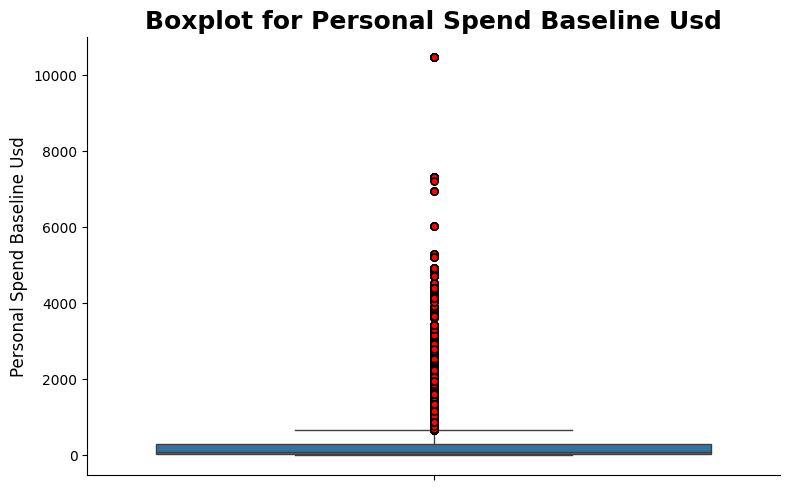

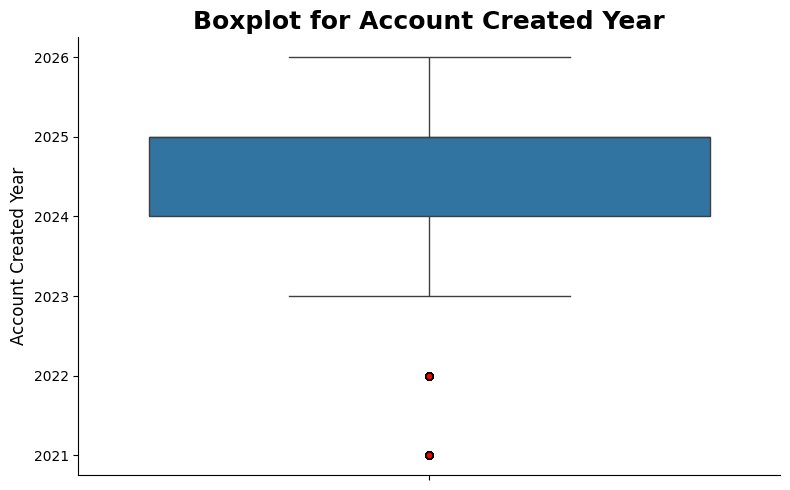

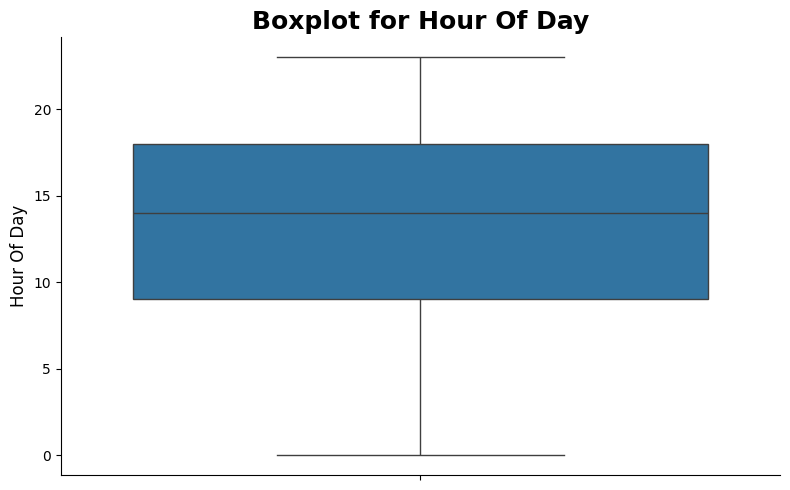

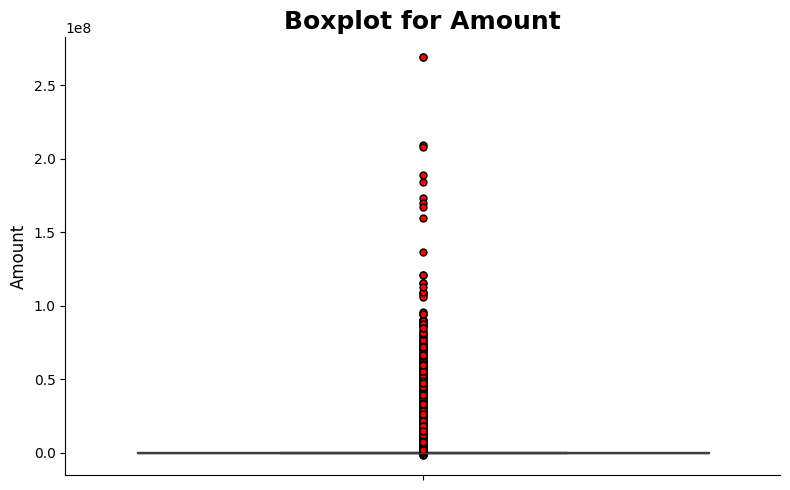

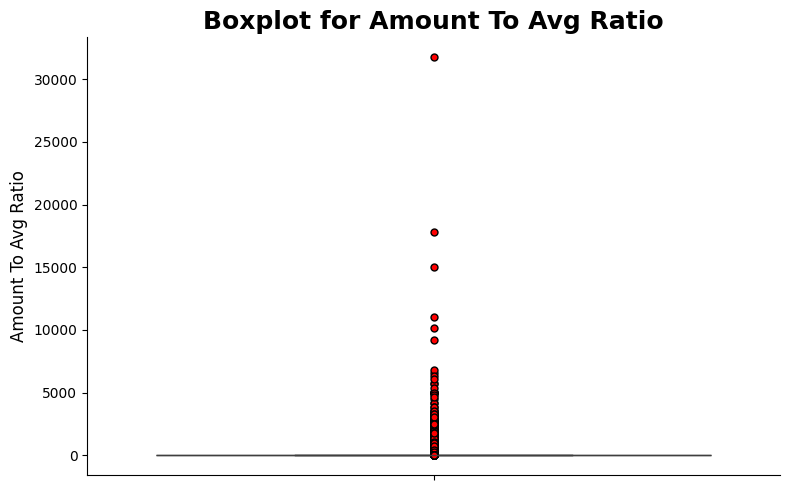

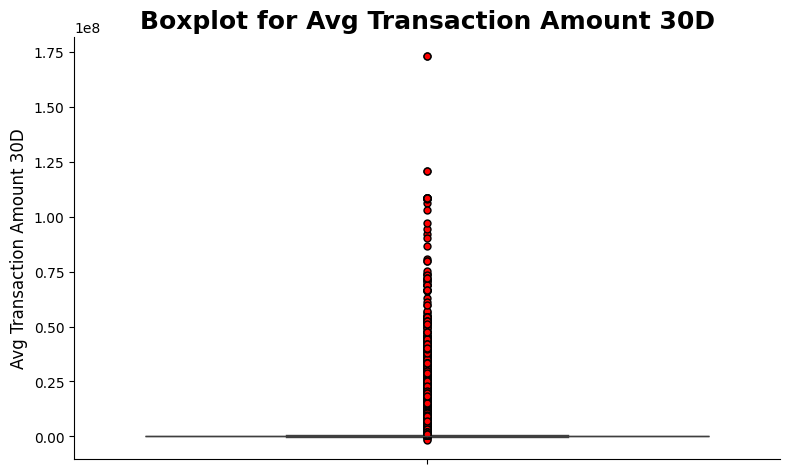

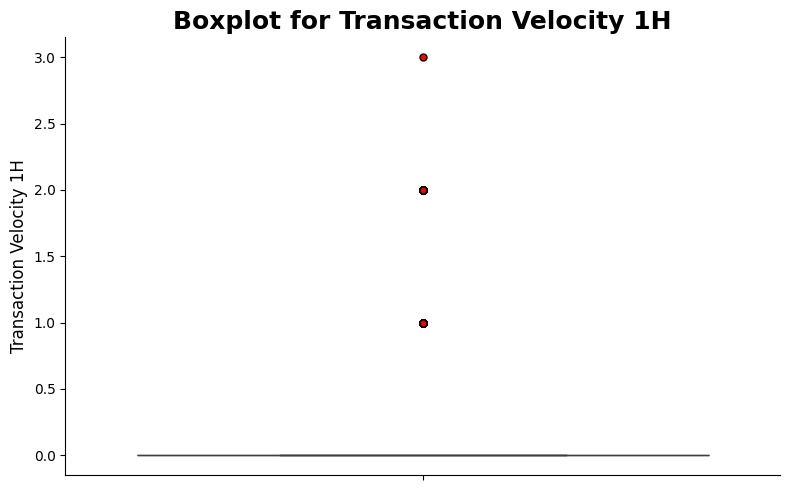

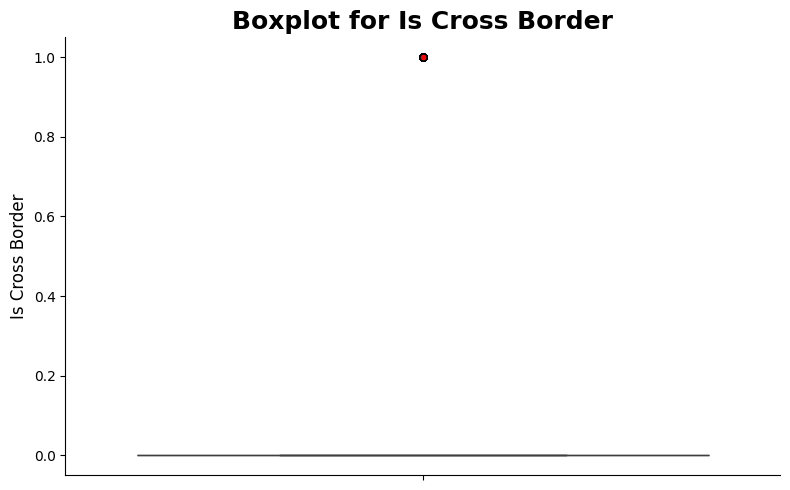

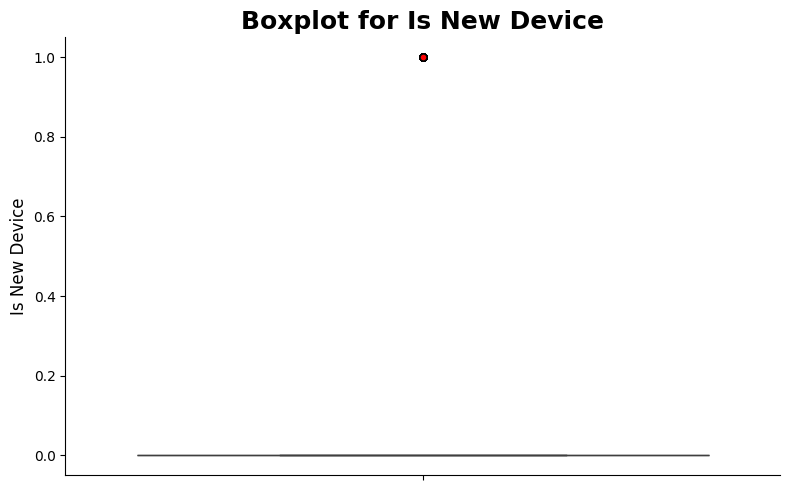

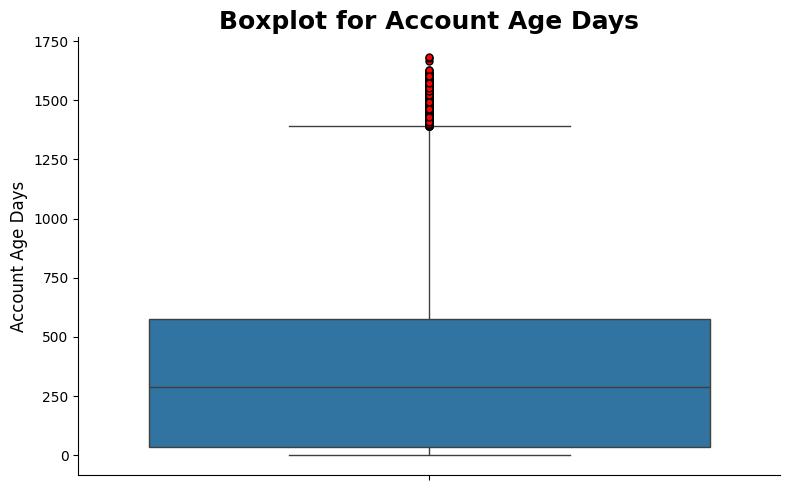

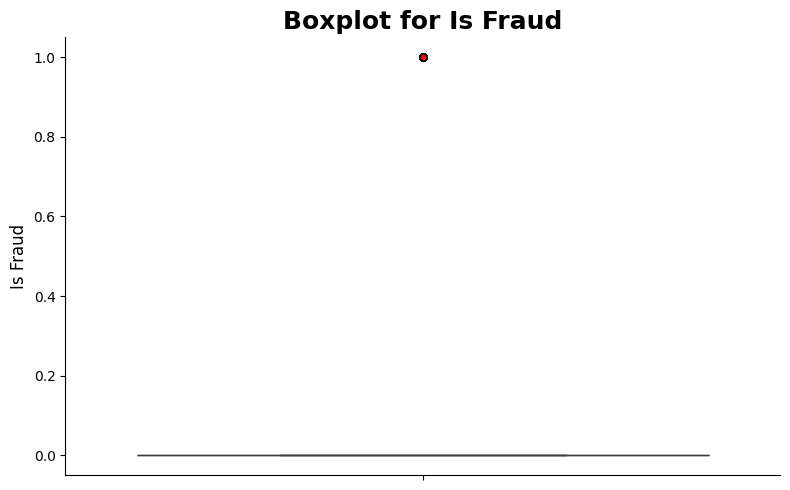

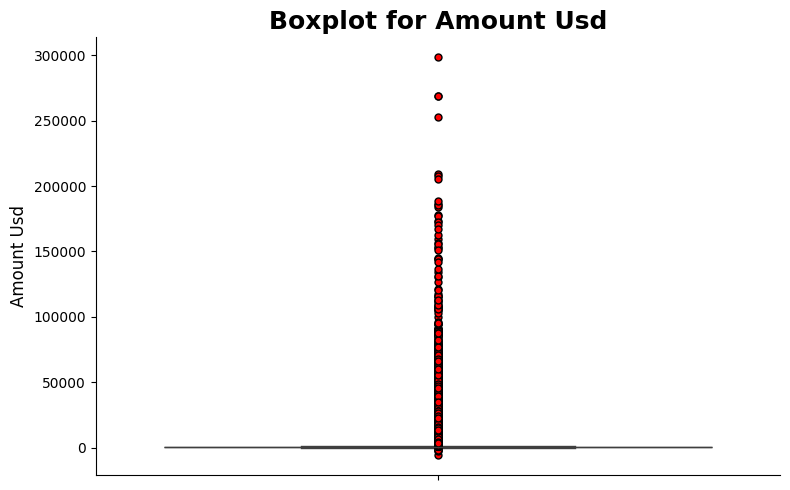

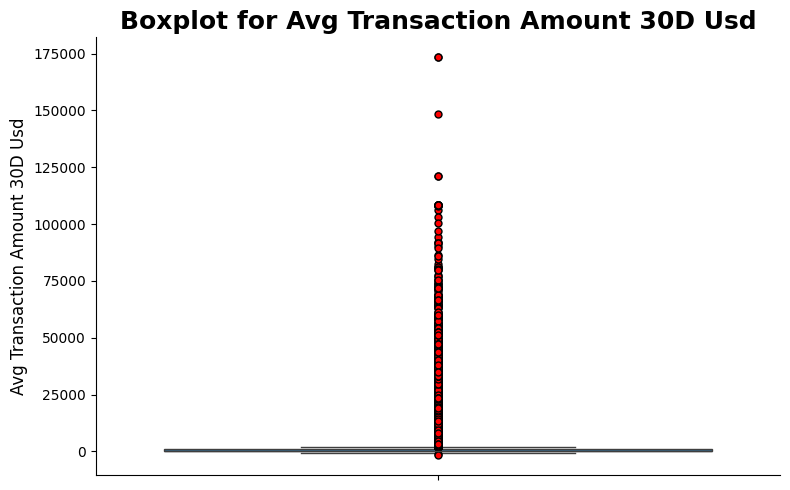

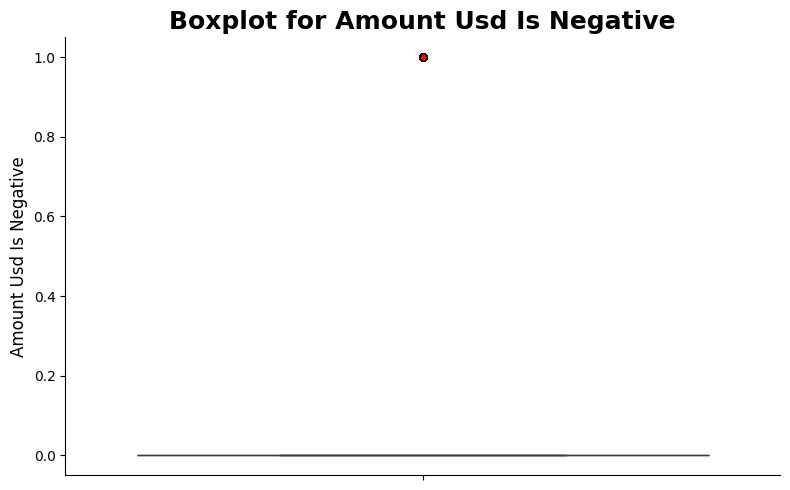

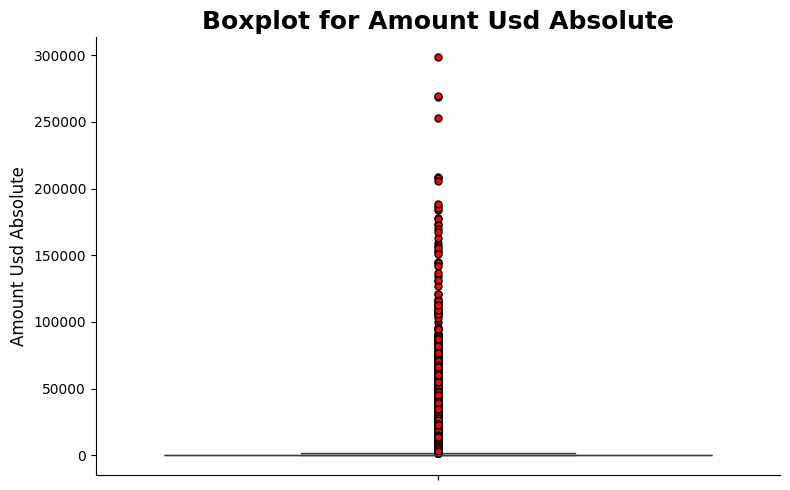

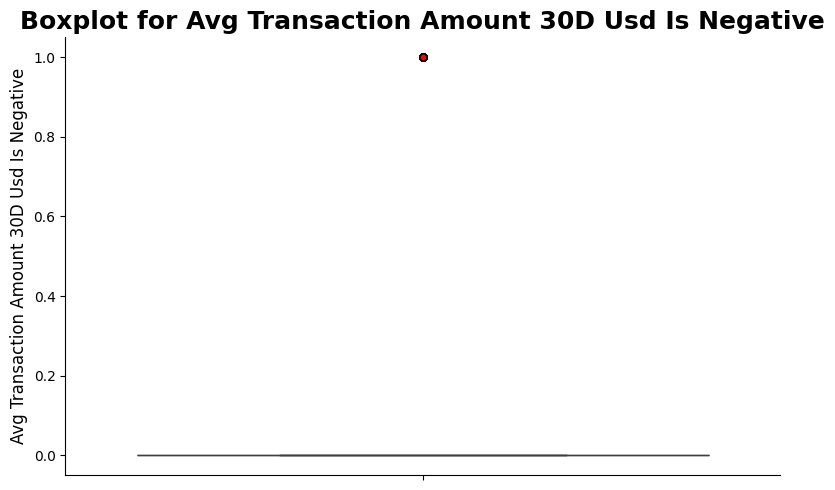

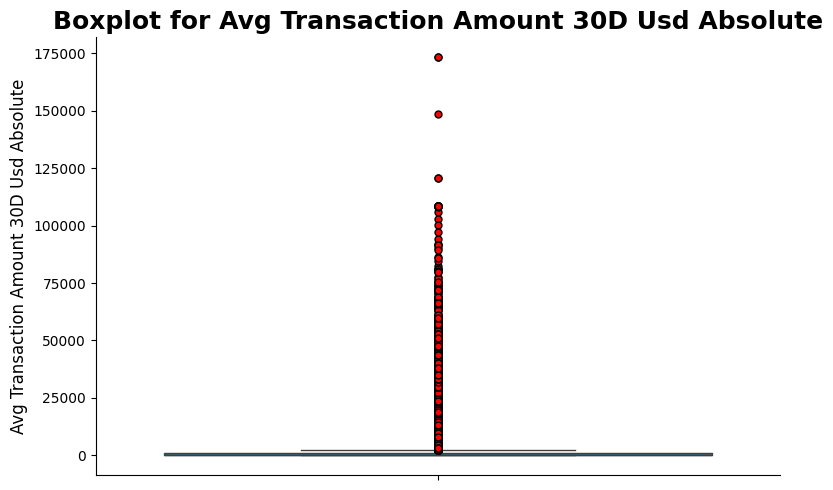

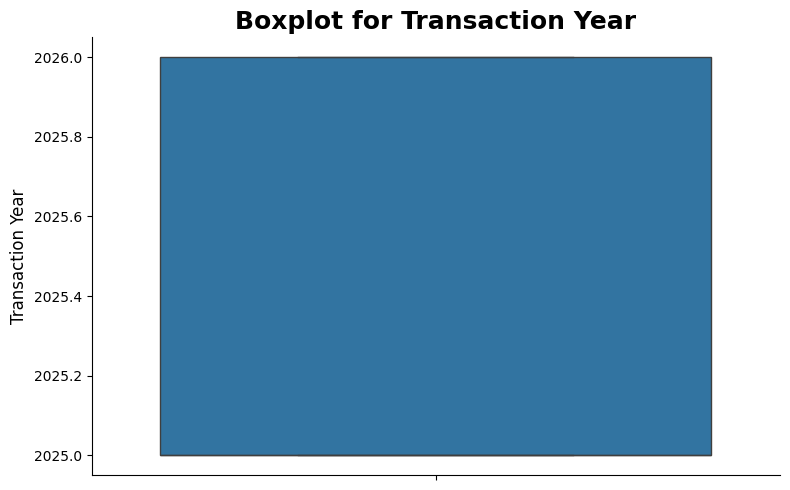

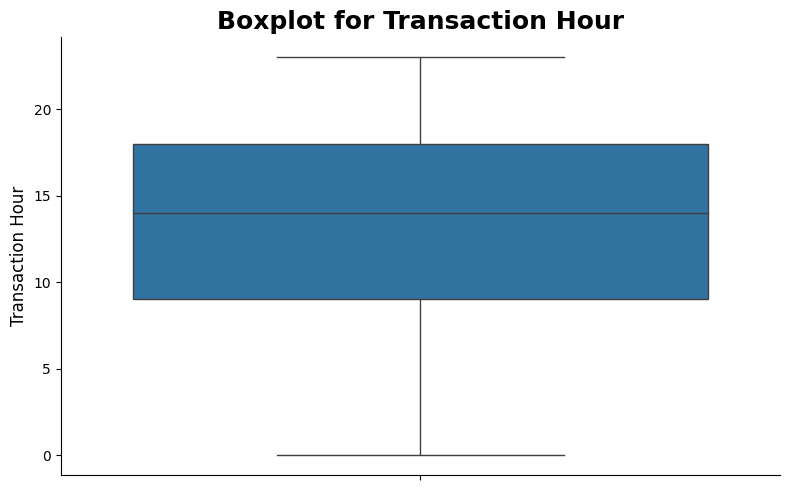

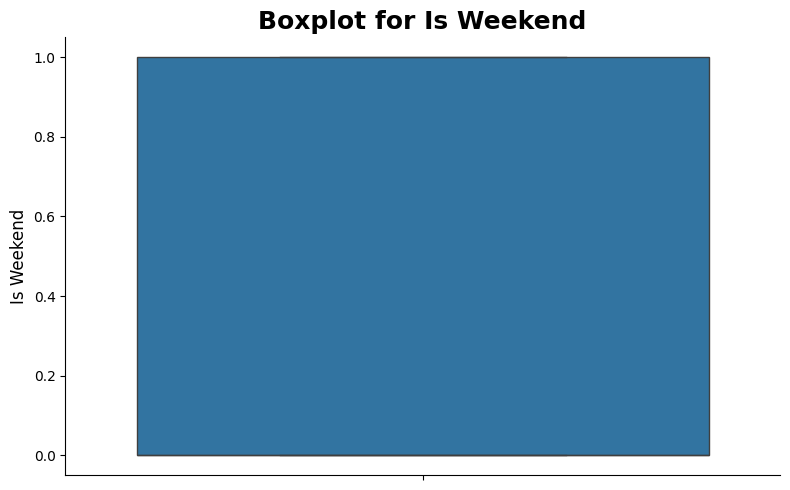

In [3]:
# ---------------------------------------------------------
# Checking for outliers in numerical columns
# ---------------------------------------------------------
# Histograms can be used to investigate the distribution
# of numerical variables.
#
# If the histograms do not clearly show potential outliers,
# boxplots can be used to confirm their presence.
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Select numerical columns automatically
numerical_columns = finlora_data.select_dtypes(
    include="number"
).columns.tolist()


# Display the numerical columns being analysed
print("Numerical columns:")
print(numerical_columns)


# ---------------------------------------------------------
# Create individual boxplots for each numerical variable
# ---------------------------------------------------------

for col in numerical_columns:

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create boxplot
    sns.boxplot(
        data=finlora_data,
        y=col,
        ax=ax,
        flierprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markersize": 5,
            "markeredgecolor": "black"
        }
    )

    # Title
    ax.set_title(
        f"Boxplot for {col.replace('_', ' ').title()}",
        fontsize=18,
        fontweight="bold"
    )

    # Axis labels
    ax.set_xlabel("")
    ax.set_ylabel(
        col.replace("_", " ").title(),
        fontsize=12
    )

    # Remove gridlines
    ax.grid(False)

    # Remove top and right borders
    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    # Improve layout
    plt.tight_layout()

    # Display plot
    plt.show()

In [4]:
finlora_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 41 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   account_id                                  126000 non-null  object 
 1   account_holder_name                         126000 non-null  object 
 2   account_type                                126000 non-null  object 
 3   home_country                                126000 non-null  object 
 4   currency                                    126000 non-null  object 
 5   kyc_tier                                    126000 non-null  object 
 6   account_created_date                        126000 non-null  object 
 7   personal_spend_baseline_usd                 126000 non-null  float64
 8   account_created_year                        126000 non-null  int64  
 9   account_created_month                       126000 non-null  object 
 

#### Removal of the Outliers using Inter-quarter Range (IQR)

In [5]:
# selecting the affected columns
affected_columns = ["avg_transaction_amount_30d_usd_absolute", "avg_transaction_amount_30d_usd_is_negative",
                    "amount_usd_absolute", "amount_usd_is_negative", "avg_transaction_amount_30d_usd", 
                    "amount_usd", "account_age_days", "is_new_device", "is_cross_border", "transaction_velocity_1h", 
                   "avg_transaction_amount_30d", "amount_to_avg_ratio", "amount","account_created_year",
                    "personal_spend_baseline_usd"]

# Computing the IQR = Q3 - Q1. N/B: Quantile is 0.25
q1 = finlora_data [affected_columns].quantile(0.25)
q3 = finlora_data [affected_columns].quantile(0.75)
iqr = q3 - q1
print(f"Inter-quarter Range (IQR) = {iqr}")

# Computing for the lower bounds & upper Bounds
"""insight: Any value lower than the lower bound is an oulier and 
Any value higher than the upper bound is also an outlier"""
lower_bound = q1 - (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

Inter-quarter Range (IQR) = avg_transaction_amount_30d_usd_absolute          837.598505
avg_transaction_amount_30d_usd_is_negative         0.000000
amount_usd_absolute                              521.112057
amount_usd_is_negative                             0.000000
avg_transaction_amount_30d_usd                   837.695607
amount_usd                                       520.964898
account_age_days                                 542.000000
is_new_device                                      0.000000
is_cross_border                                    0.000000
transaction_velocity_1h                            0.000000
avg_transaction_amount_30d                    157477.670000
amount_to_avg_ratio                                1.580000
amount                                        120783.932500
account_created_year                               1.000000
personal_spend_baseline_usd                      251.720000
dtype: float64


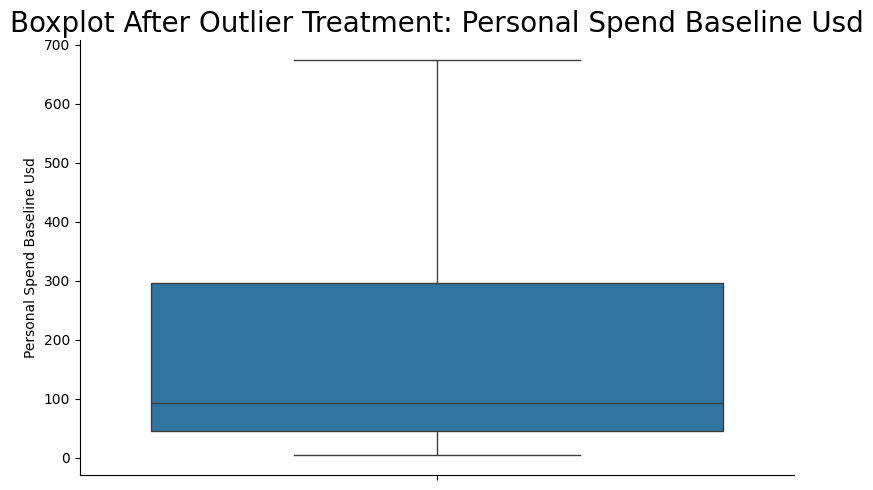

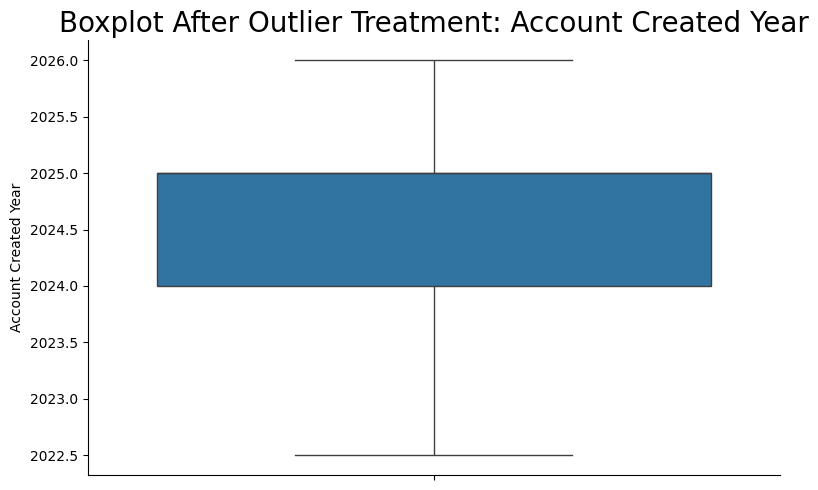

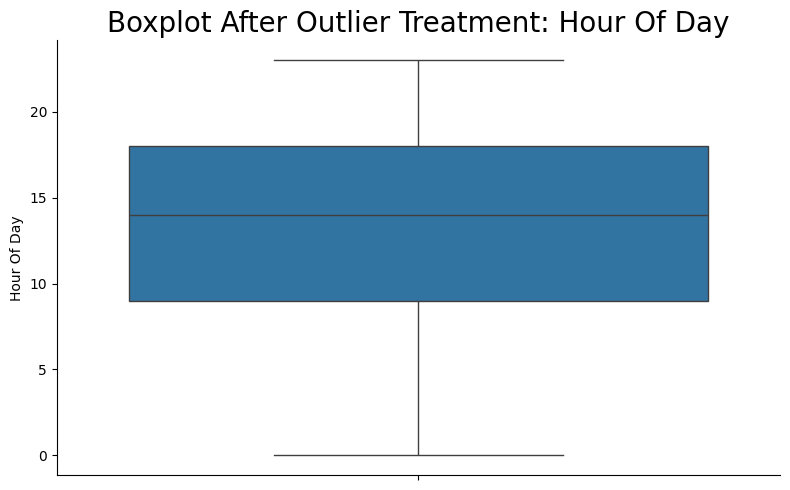

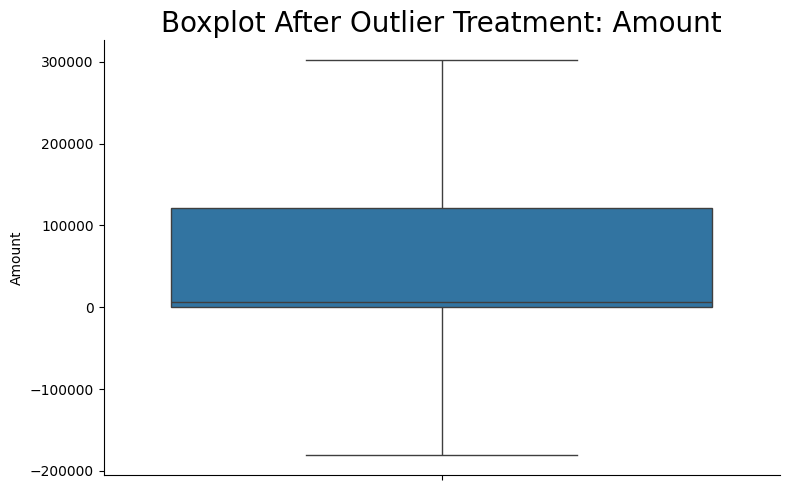

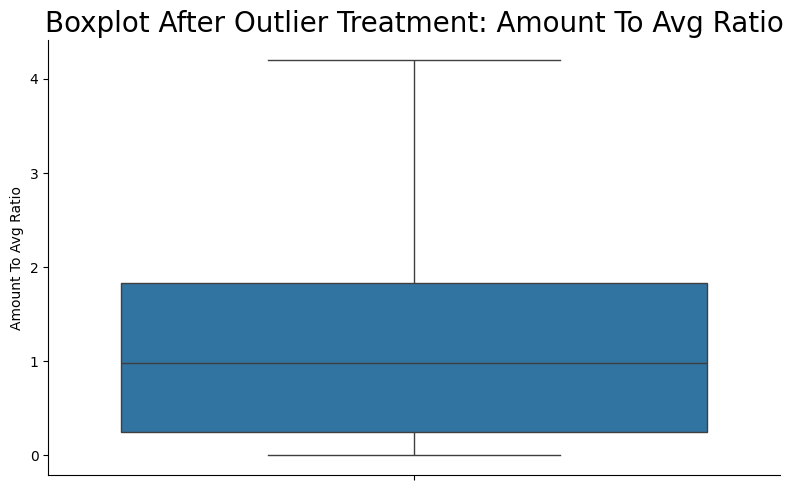

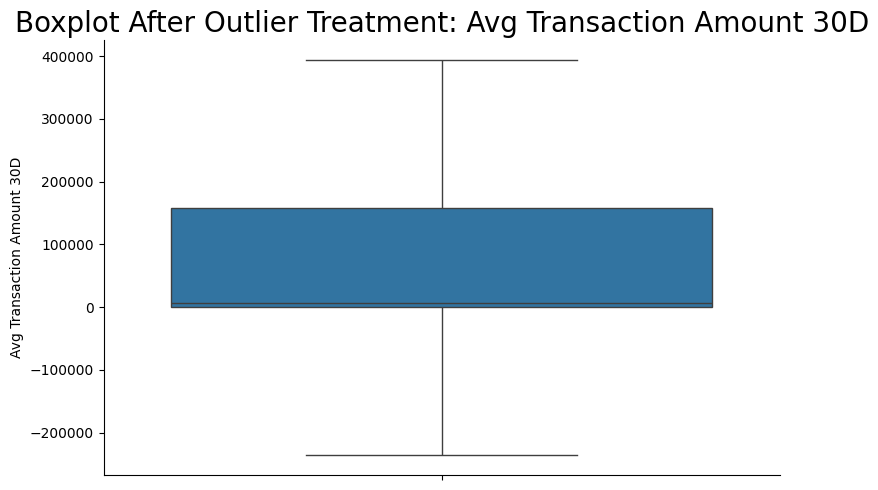

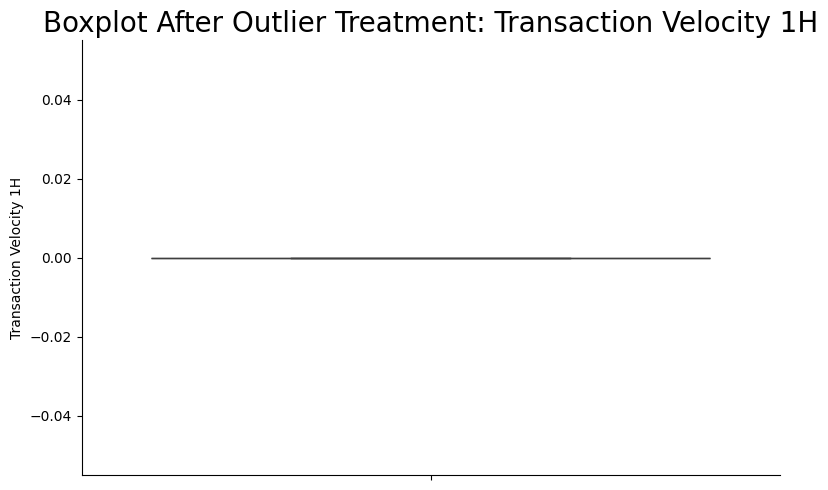

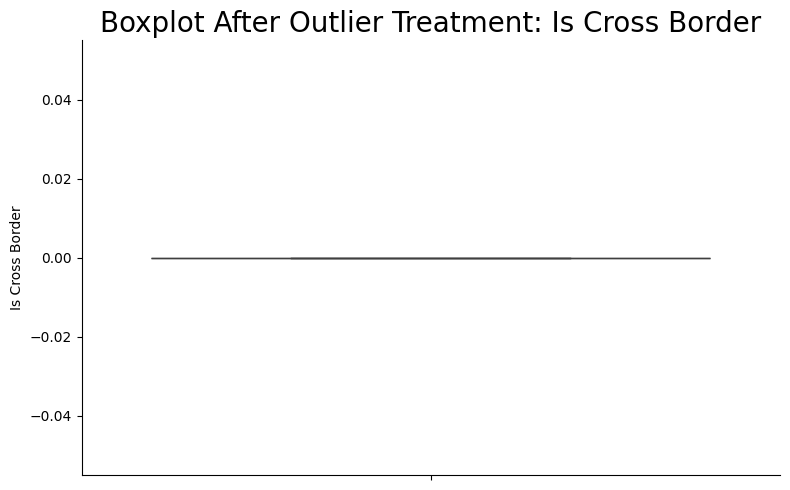

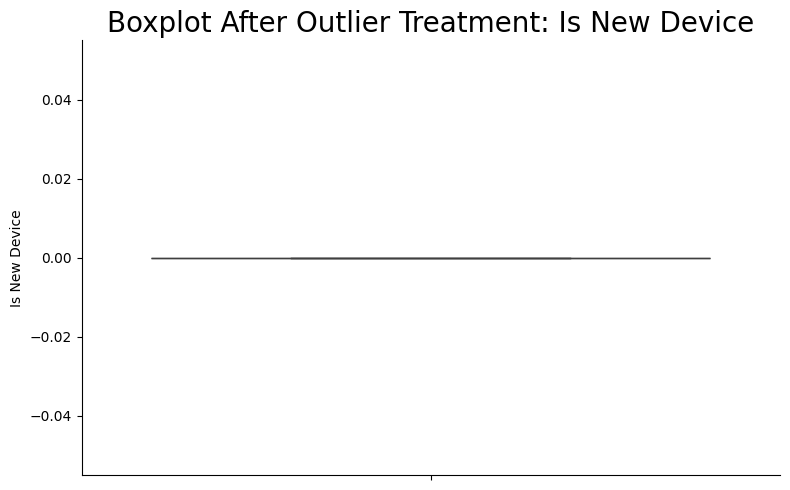

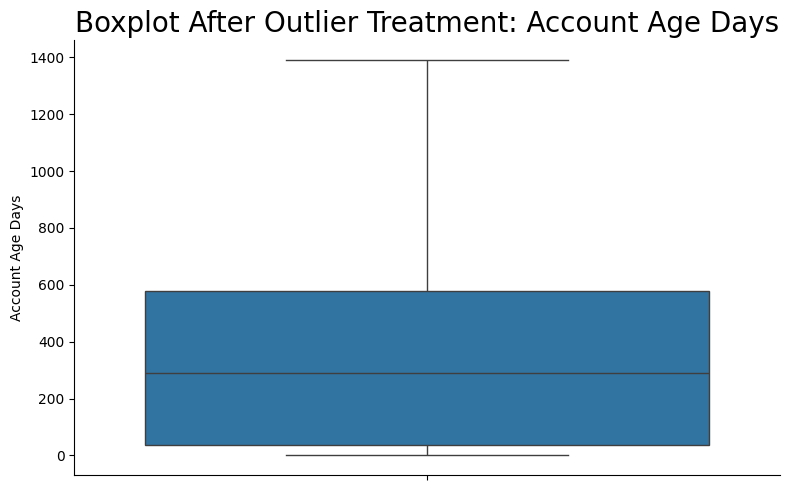

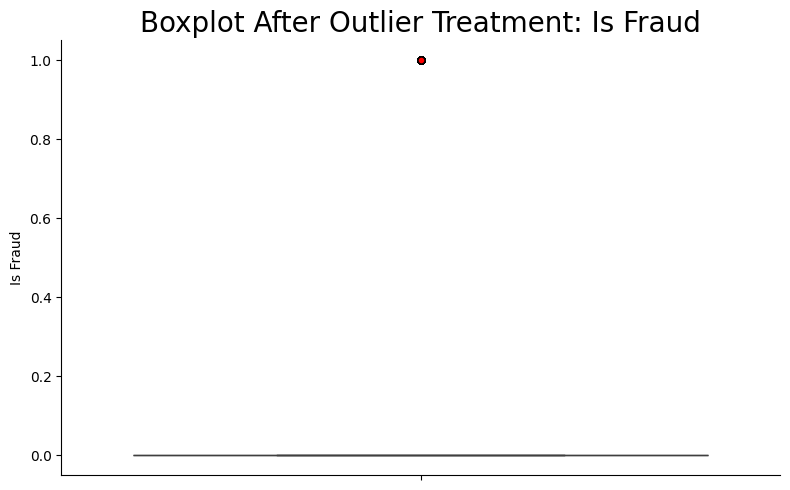

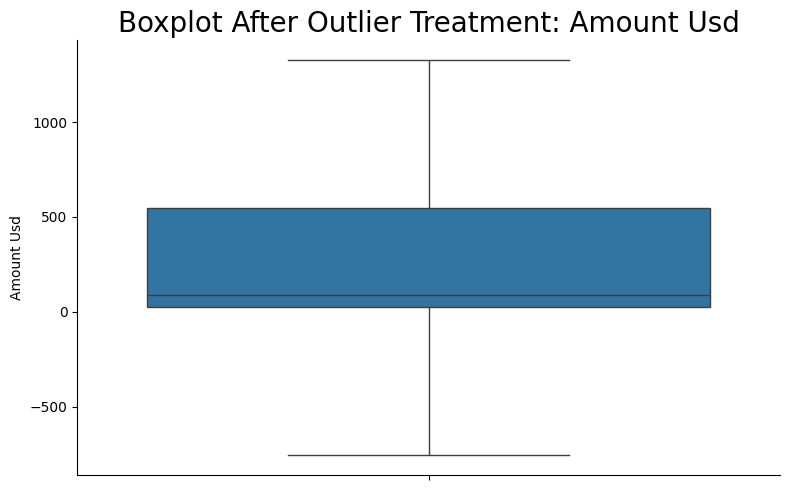

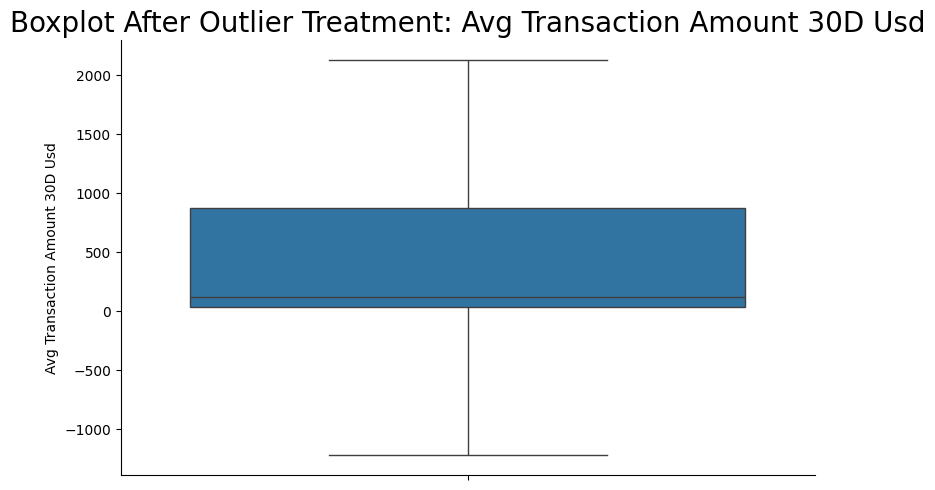

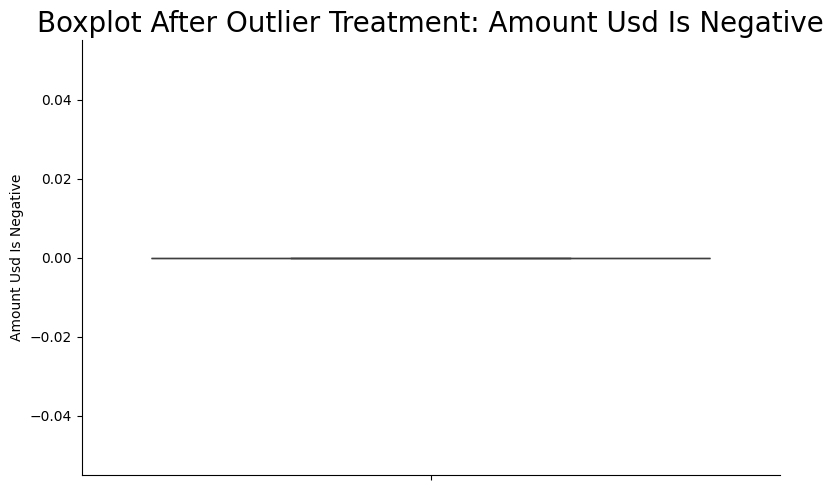

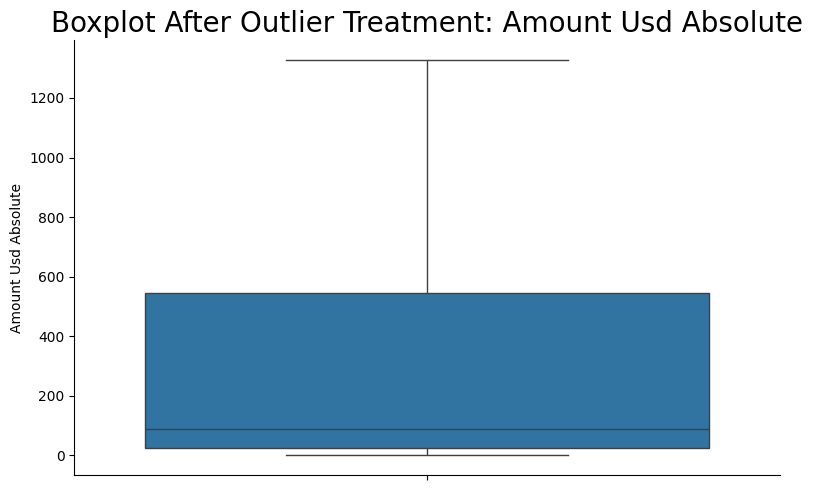

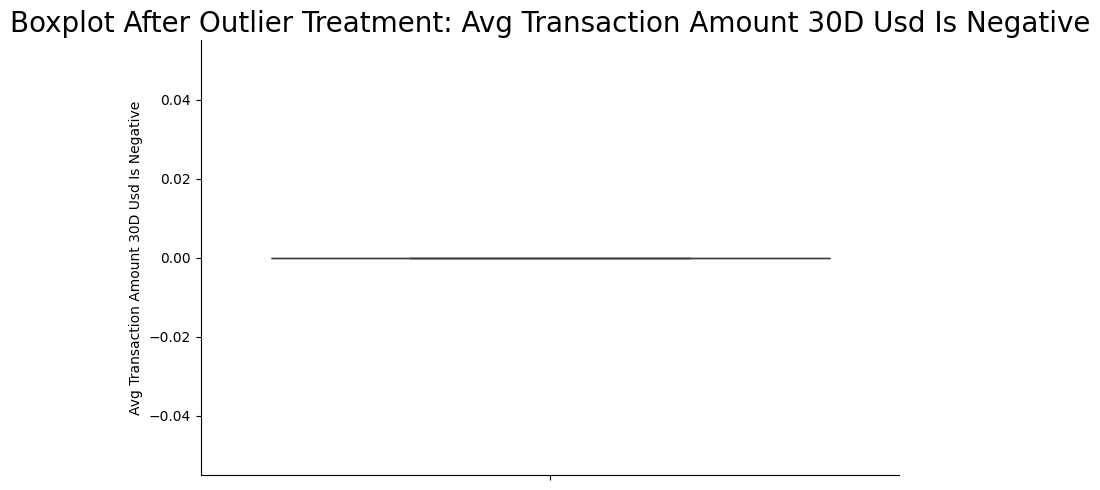

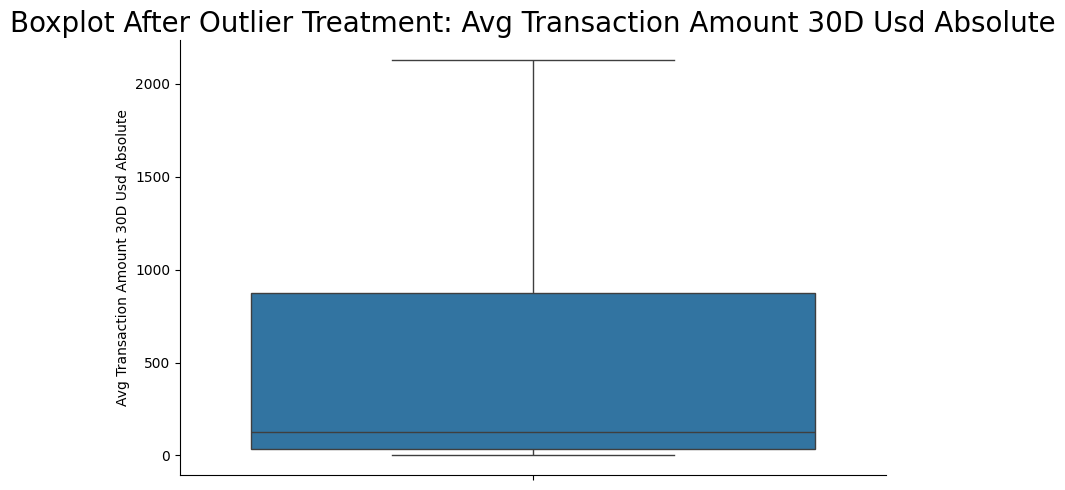

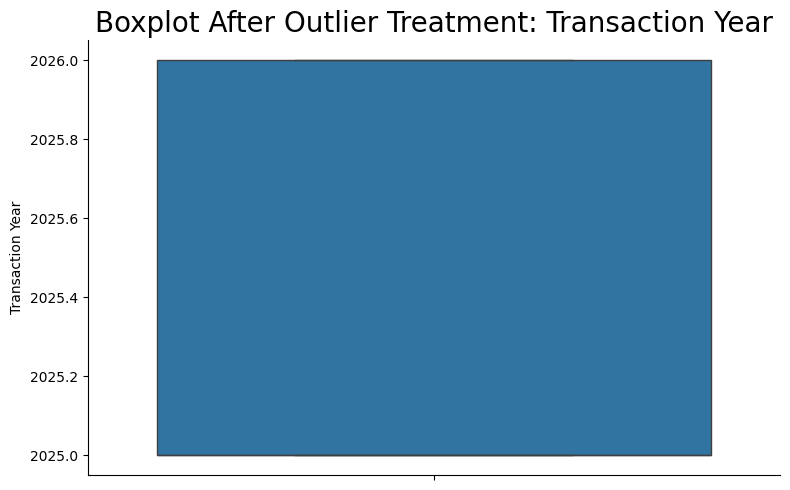

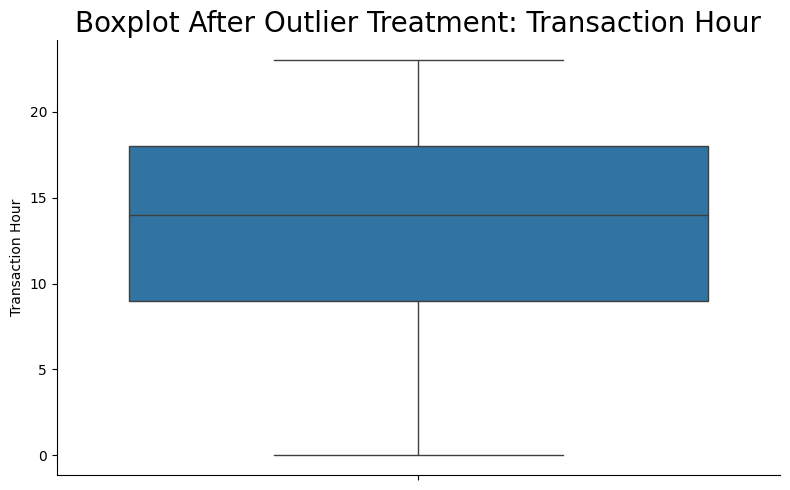

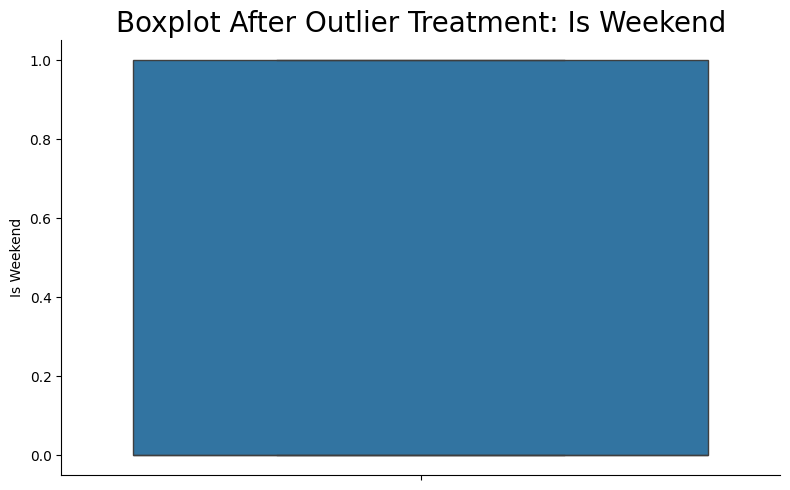

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Clip the lower and upper bounds
# ---------------------------------------------------------

finlora_data[affected_columns] = (
    finlora_data[affected_columns]
    .clip(
        lower=lower_bound,
        upper=upper_bound,
        axis=1
    )
)


# ---------------------------------------------------------
# 2. Verify that outliers have been handled
# ---------------------------------------------------------

for col in numerical_columns:

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create boxplot
    sns.boxplot(
        data=finlora_data,
        y=col,
        ax=ax,
        flierprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markersize": 5,
            "markeredgecolor": "black"
        }
    )

    # Remove top and right borders
    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    # Title
    ax.set_title(
        f"Boxplot After Outlier Treatment: "
        f"{col.replace('_', ' ').title()}",
        fontsize=20
    )

    # Axis labels
    ax.set_xlabel("")
    ax.set_ylabel(
        col.replace("_", " ").title()
    )

    # Remove gridlines
    ax.grid(False)

    # Improve spacing
    plt.tight_layout()

    # Display
    plt.show()

#### ADDED FEATURES

In [7]:
# ADDED FEATURES
# ============================================================

# 1. Unusual transaction amount
# ------------------------------------------------------------

# Amount compared with the customer's 30-day average
finlora_data["amount_deviation_ratio"] = (
    finlora_data["amount_to_avg_ratio"]
)

# Flag transactions that are at least 3 times the average
finlora_data["high_amount_deviation"] = (
    finlora_data["amount_to_avg_ratio"] >= 3
).astype(int)


# 2. High transaction velocity
# ------------------------------------------------------------

finlora_data["high_velocity"] = (
    finlora_data["transaction_velocity_1h"] >= 3
).astype(int)



# 3. Large transaction relative to personal baseline
# ------------------------------------------------------------

finlora_data["large_transaction"] = (
    finlora_data["amount_usd"] >
    finlora_data["personal_spend_baseline_usd"] * 3
).astype(int)



# 4. New device indicator
# ------------------------------------------------------------

finlora_data["new_device_flag"] = (
    finlora_data["is_new_device"]
    .fillna(0)
    .astype(int)
)



# 5. Cross-border transaction indicator
# ------------------------------------------------------------

finlora_data["cross_border_flag"] = (
    finlora_data["is_cross_border"]
    .fillna(0)
    .astype(int)
)



# 6. New device + cross-border combination
# ------------------------------------------------------------

# A transaction involving both a new device and
# cross-border activity can represent a stronger
# behavioural signal than either feature individually.

finlora_data["device_country_risk"] = (
    finlora_data["new_device_flag"] *
    finlora_data["cross_border_flag"]
)



# 7. Account age features
# ------------------------------------------------------------

finlora_data["new_account_flag"] = (
    finlora_data["account_age_days"] <= 30
).astype(int)

finlora_data["young_account_flag"] = (
    finlora_data["account_age_days"] <= 100
).astype(int)

finlora_data["old_account_flag"] = (
    finlora_data["account_age_days"] > 100
).astype(int)



# 8. Unusual transaction during unusual hours
# ------------------------------------------------------------

# Define unusual hours as midnight to 05:00
finlora_data["unusual_hour"] = (
    (finlora_data["transaction_hour"] >= 0) &
    (finlora_data["transaction_hour"] < 5)
).astype(int)



# 9. High amount + high velocity
# ------------------------------------------------------------

finlora_data["amount_velocity_risk"] = (
    finlora_data["high_amount_deviation"] *
    finlora_data["high_velocity"]
)



# 10. Combined behavioural risk indicator
# ------------------------------------------------------------

finlora_data["combined_behaviour_risk"] = (
    finlora_data["high_amount_deviation"] +
    finlora_data["high_velocity"] +
    finlora_data["new_device_flag"] +
    finlora_data["cross_border_flag"] +
    finlora_data["new_account_flag"]
)



# 11. Display engineered features
# ------------------------------------------------------------

engineered_features = [
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "is_weekend",
    "amount_deviation_ratio",
    "high_amount_deviation",
    "transaction_velocity_1h",
    "high_velocity",
    "large_transaction",
    "new_device_flag",
    "cross_border_flag",
    "device_country_risk",
    "new_account_flag",
    "young_account_flag",
    "old_account_flag",
    "unusual_hour",
    "amount_velocity_risk",
    "combined_behaviour_risk"
]

print("\nEngineered Features:")
print(engineered_features)

print("\nSample of engineered data:")
print(
    finlora_data[
        ["account_id", "amount_usd", "is_fraud"] +
        engineered_features
    ].head()
)



print(
    f"\nFeature-engineered dataset successful:\n")


Engineered Features:
['transaction_hour', 'transaction_day', 'transaction_month', 'is_weekend', 'amount_deviation_ratio', 'high_amount_deviation', 'transaction_velocity_1h', 'high_velocity', 'large_transaction', 'new_device_flag', 'cross_border_flag', 'device_country_risk', 'new_account_flag', 'young_account_flag', 'old_account_flag', 'unusual_hour', 'amount_velocity_risk', 'combined_behaviour_risk']

Sample of engineered data:
       account_id  amount_usd  is_fraud  transaction_hour transaction_day  \
0  FLR-ACC-100000    84.23300         0                14          Sunday   
1  FLR-ACC-100000     9.14333         0                13       Wednesday   
2  FLR-ACC-100000    20.63900         0                12        Thursday   
3  FLR-ACC-100000     3.17743         0                14          Monday   
4  FLR-ACC-100000    97.83952         0                16        Saturday   

  transaction_month  is_weekend  amount_deviation_ratio  \
0          February           1              

### Removal of Irrelevant Columns/Features/Variables

In [8]:
# Drop Irrelevant attriutes that contributes less to the analysis or cause data imbalance and leakage to model traning.
drop_data = ["transaction_id", "account_id", "account_holder_name", "description", "merchant_category", "device_id",
             "timestamp", "account_created_date","home_country","account_created_year", "account_created_month","account_created_day",
            "day_of_week", "hour_of_day", "amount", "avg_transaction_amount_30d"]
finlora_data = finlora_data.drop(columns=drop_data)
print(f"Remaining Usable Columns:", list(finlora_data.columns))   

Remaining Usable Columns: ['account_type', 'currency', 'kyc_tier', 'personal_spend_baseline_usd', 'merchant_name', 'channel', 'amount_to_avg_ratio', 'transaction_velocity_1h', 'transaction_country', 'is_cross_border', 'is_new_device', 'account_age_days', 'status', 'is_fraud', 'amount_usd', 'avg_transaction_amount_30d_usd', 'amount_usd_is_negative', 'amount_usd_absolute', 'avg_transaction_amount_30d_usd_is_negative', 'avg_transaction_amount_30d_usd_absolute', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_hour', 'is_weekend', 'amount_deviation_ratio', 'high_amount_deviation', 'high_velocity', 'large_transaction', 'new_device_flag', 'cross_border_flag', 'device_country_risk', 'new_account_flag', 'young_account_flag', 'old_account_flag', 'unusual_hour', 'amount_velocity_risk', 'combined_behaviour_risk']


In [9]:
finlora_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 38 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   account_type                                126000 non-null  object 
 1   currency                                    126000 non-null  object 
 2   kyc_tier                                    126000 non-null  object 
 3   personal_spend_baseline_usd                 126000 non-null  float64
 4   merchant_name                               126000 non-null  object 
 5   channel                                     126000 non-null  object 
 6   amount_to_avg_ratio                         126000 non-null  float64
 7   transaction_velocity_1h                     126000 non-null  int64  
 8   transaction_country                         126000 non-null  object 
 9   is_cross_border                             126000 non-null  int64  
 

### Encoding Categorical Variables using (labeencoder or one-hot encoder)
converting categoricl variables like "account_type", "currency", "kyc_tier", "merchant_name",
    "channel", "transaction_country", "status", "transaction_month", "transaction_day" into numerical formats

In [10]:
# # One-Hot Encode categorical columns
# categorical_columns = ["account_type", "currency", "kyc_tier", "merchant_name",
#     "channel", "transaction_country", "status", "transaction_month", "transaction_day"]

# featured_data = pd.get_dummies(finlora_data, columns=categorical_columns, drop_first=True, dtype=int)

# print("Original shape:", finlora_data.shape)
# print("Shape after encoding:", featured_data.shape)
# print("-" * 40)



# # Feature-Engineered Data Summary
# duplicate_values = []

# for col in featured_data.columns:
#     duplicate_values.append(featured_data[col].duplicated().sum())

# engineered_data_summary = pd.DataFrame({
#     "Data Type": featured_data.dtypes.astype(str),
#     "Missing Values": featured_data.isna().sum(), 
#     "% Missing Values": (featured_data.isna().mean() * 100).round(2),
#     "Unique Values": featured_data.nunique(), 
#     "Duplicate Values": duplicate_values}).sort_values("% Missing Values", ascending=False)


# engineered_data_summary

In [11]:
featured_data.head()

NameError: name 'featured_data' is not defined

### Scaling Numerical Features
scale to bring them to a similar ranges which can improve the model performance

IndexError: index 20 is out of bounds for axis 0 with size 20

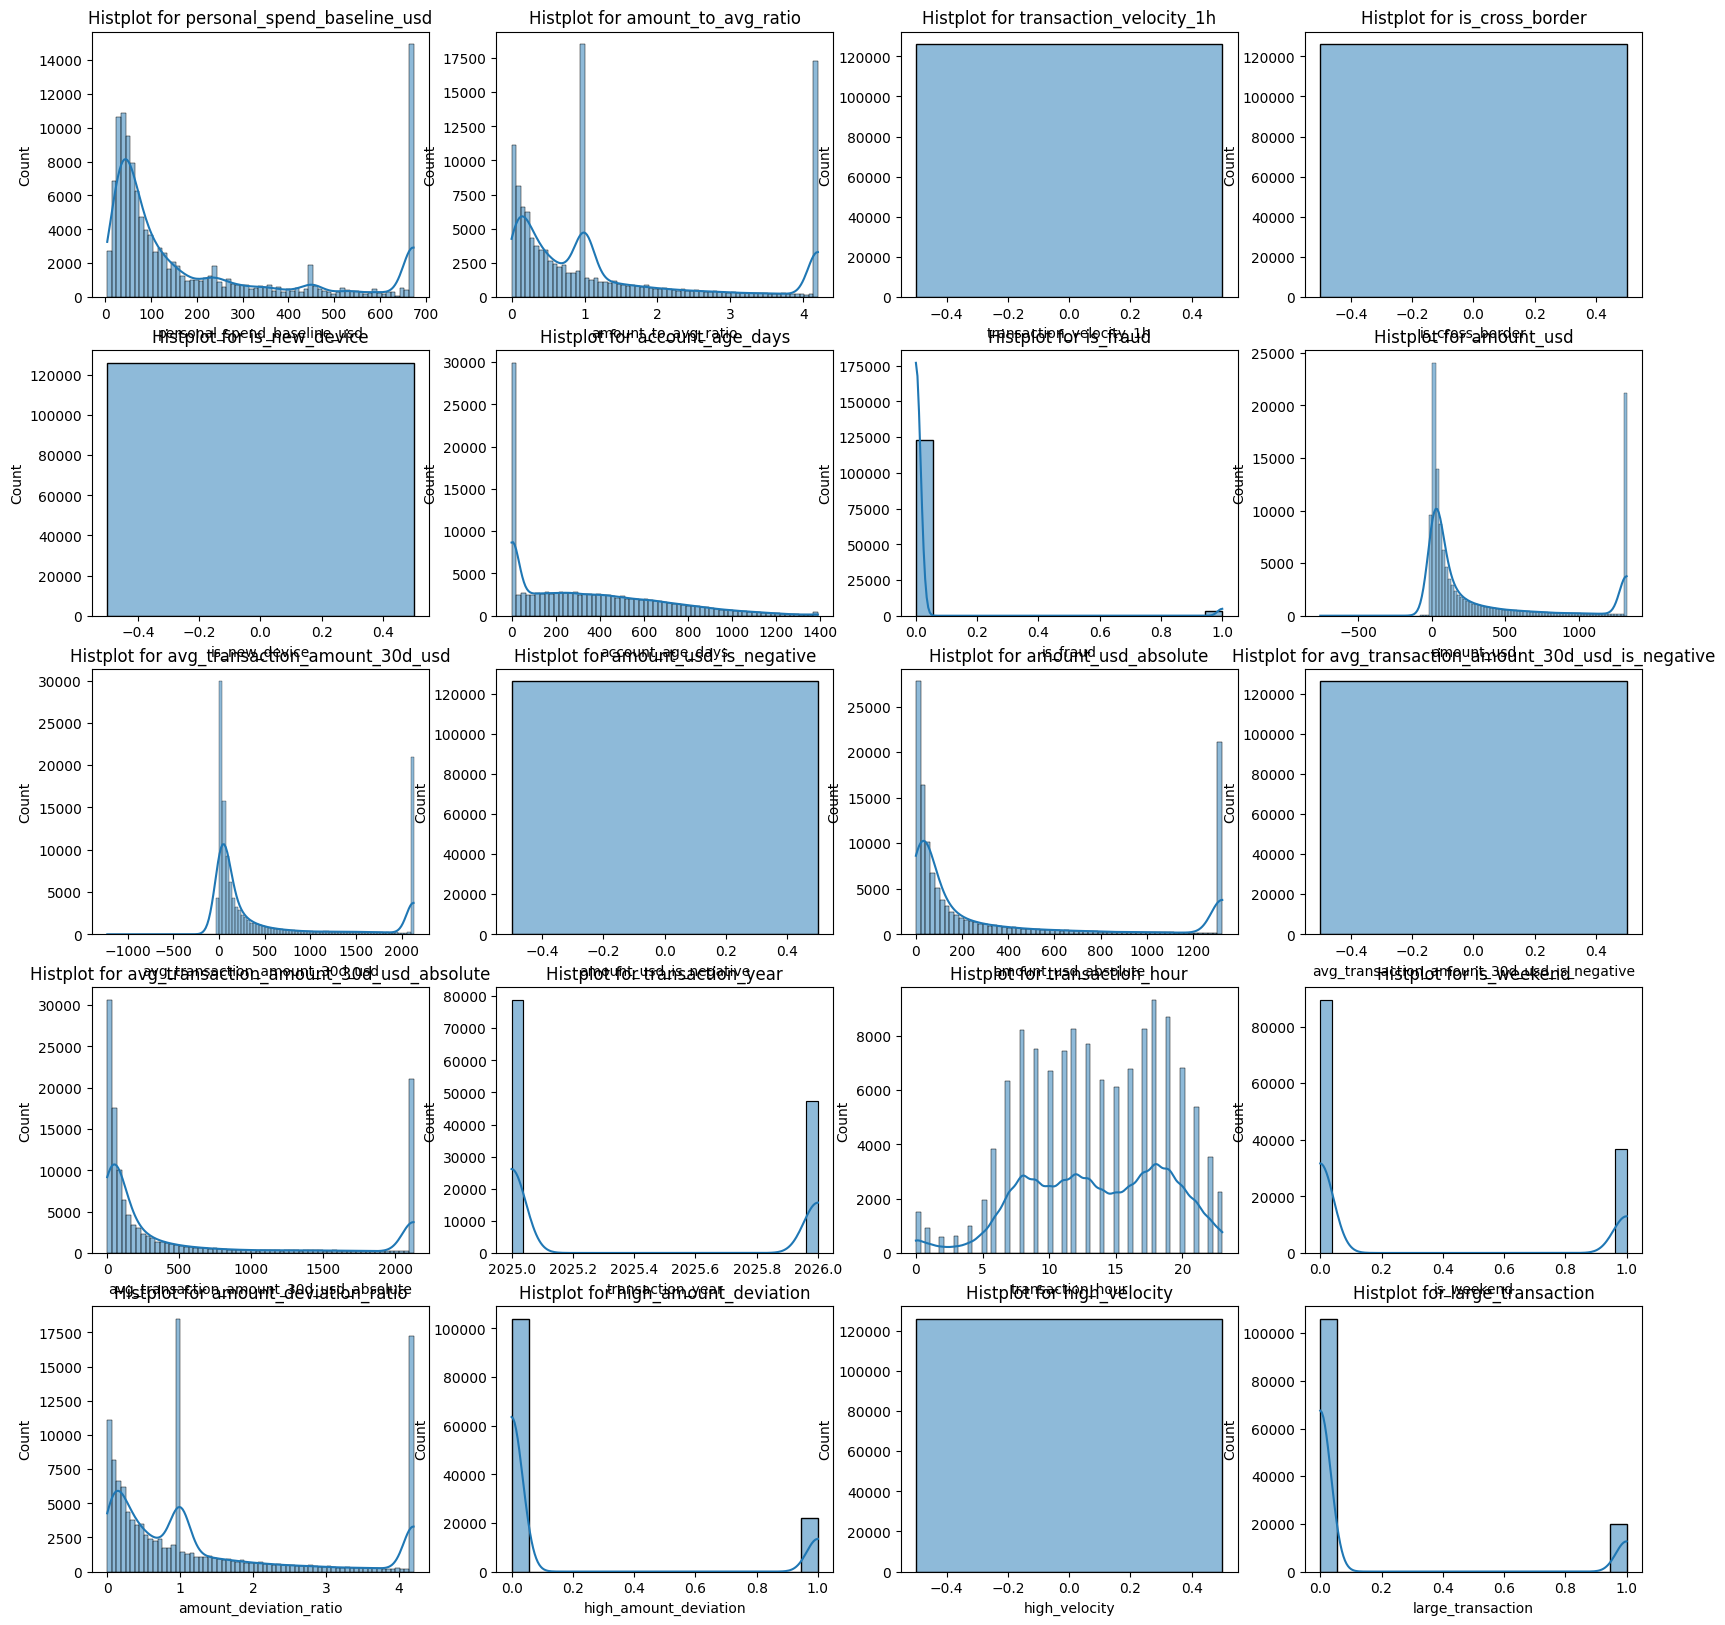

In [13]:
# checking for outliers in numerical column
# investigate numerical columns for outliers via visualization of their distribution on histplots
"""if the plot are not too convincing to show the presence of outlier, 
use box plot to confirm the truthfulness"""
# selecting numerical columns
numerical_columns = finlora_data.select_dtypes(include="number")
len(numerical_columns.columns)

# visualization
fig,ax = plt.subplots(nrows=5,ncols=4, figsize=(20,20))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(finlora_data[col], ax=ax[idx],kde=True)
    ax[idx].set_title(f"Histplot for {col}")
plt.show()

In [ ]:
# num_cols_to_scale = ["avg_transaction_amount_30d_usd_absolute", "avg_transaction_amount_30d_usd_is_negative",
#                     "amount_usd_absolute", "amount_usd_is_negative", "avg_transaction_amount_30d_usd", 
#                     "amount_usd", "account_age_days", "is_new_device", "is_cross_border", "transaction_velocity_1h", 
#                     "amount_to_avg_ratio", "personal_spend_baseline_usd"]
# """N/B: if the plotted outliers are normal/slightly skewed use(StandardScaler),
# if its uniformly distributed use(MinMaxScaler),
# if it is heavily skewed distribution use(RobostScaler)"""


# """In This case data is Heavily skewed"""

In [ ]:
# # Initializing the Scaler
# scaler = RobustScaler()

# # Scaling/ fitting the dataset
# featured_data[num_cols_to_scale] = scaler.fit_transform(featured_data[num_cols_to_scale])

# featured_data.head()

#### Featured Engineered Dataset is ready

In [15]:
# Save the featured dataset as a new CSV file
output_folder = r"C:\Users\User\Documents\10anlyticsDS\Projects\PersonalPJ\AMDARI_PJ\Dataset\feat_engineered_data"

os.makedirs(output_folder, exist_ok=True)

# Save the featured dataset
output_file = os.path.join(output_folder, "Featured_Engineered_Data.csv")

finlora_data.to_csv(output_file, index=False)

# 5. Confirm the result
print("Feateured Engineer dataset created successfully!")
print("Rows and columns:", finlora_data.shape)
print("File saved as: Featured_Engineered_Data.csv")

Feateured Engineer dataset created successfully!
Rows and columns: (126000, 38)
File saved as: Featured_Engineered_Data.csv
